## Image classification Models

In [1]:
import sys

sys.modules["IPython"] = None
sys.stderr = sys.stdout

import warnings

warnings.filterwarnings("ignore")

import os

os.environ["PYTHONWARNINGS"] = "ignore"

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.transforms import v2 as transforms

In [ ]:
import multiprocessing as mp

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

from optuna import logging, create_study
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.exceptions import TrialPruned

logging.set_verbosity(logging.WARNING)

from captum.attr import IntegratedGradients

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import textwrap
from tqdm import tqdm

In [ ]:
import os
import numpy as np
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

In [7]:
import tifffile as tiff
from torch.utils.data import Dataset

In [8]:
class TifImageDataset(Dataset):

    def __init__(self, imgs_dir, labels_file=None, transforms=None):
        self.imgs_dir = imgs_dir
        if labels_file is None:
            self.ids = np.array([f.split(".")[0] for f in os.listdir(imgs_dir)])
            self.labels = None
        else:
            df = pd.read_csv(labels_file)
            self.ids = df["id"].to_numpy()
            self.labels = df["label"].to_numpy()
        self.transforms = transforms

    def __len__(self):
        return self.ids.shape[0]

    def __getitem__(self, idx):
        image = tiff.imread(os.path.join(self.imgs_dir, self.ids[idx] + ".tif"))
        if self.transforms is not None:
            image = self.transforms(image)
        return (image,) if self.labels is None else (image, self.labels[idx])

In [9]:
def imshow(imgs, titles, max_cols=5):
    n_imgs = len(imgs)
    n_rows = int(np.ceil(n_imgs / max_cols))
    n_cols = n_imgs if n_imgs <= max_cols else max_cols

    _, axes = plt.subplots(nrows=n_rows, ncols=n_cols, squeeze=False)

    for i in range(n_rows):
        for j in range(n_cols):
            if j + n_cols * i < n_imgs:
                axes[i][j].imshow(imgs[j + n_cols * i])
                axes[i][j].set_title(f"{titles[j + n_cols * i]}")
                axes[i][j].set_xticks([])
                axes[i][j].set_yticks([])
            else:
                axes[i][j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# source directory where the 400X images are located
source_directory = "Data science/BreaKHis_v1/histology_slides"

# Target directory where to collect the 400X images
target_directory = "dataset"

os.makedirs(target_directory, exist_ok=True)

# Function to copy 400X images from subfolders to the target directory
def copy_400X_images(source_dir, target_dir):
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if "400x" in root.lower():
                image_path = os.path.join(root, file)
                target_class = "benign" if "benign" in root.lower() else "malignant"
                class_dir = os.path.join(target_dir, target_class)
                os.makedirs(class_dir, exist_ok=True)
                shutil.copy(image_path, os.path.join(class_dir, file))

# Copy 400X images to the target directories based on class
copy_400X_images(source_directory, target_directory)

print("Copying 400X images completed.")


Copying 400X images completed.


In [ ]:
import os
import random
from shutil import copyfile

#  paths to dataset folders
data_dir = "C:/Users/Kompal/Desktop/Data science/dataset"
benign_dir = os.path.join(data_dir, 'benign')
malignant_dir = os.path.join(data_dir, 'malignant')

#  the directories for the training and testing sets
train_dir = "C:/Users/Kompal/Desktop/Data science/train"
test_dir = "C:/Users/Kompal/Desktop/Data science/test"

# Check if the source directories exist
if not os.path.exists(benign_dir) or not os.path.exists(malignant_dir):
    raise FileNotFoundError("Source directories for benign or malignant images do not exist.")

# Create the training and testing directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Define the ratio of images to use for testing
test_ratio = 0.2

# Create subdirectories in the train and test directories
os.makedirs(os.path.join(train_dir, 'benign'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'malignant'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'benign'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'malignant'), exist_ok=True)

#  all image files in the benign and malignant directories
benign_images = [f for f in os.listdir(benign_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
malignant_images = [f for f in os.listdir(malignant_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

random.shuffle(benign_images)
random.shuffle(malignant_images)

# the number of images to use for testing
num_benign_test = int(test_ratio * len(benign_images))
num_malignant_test = int(test_ratio * len(malignant_images))

# Function to safely copy files and handle errors
def safe_copy(src, dst):
    try:
        copyfile(src, dst)
    except Exception as e:
        print(f"Error copying {src} to {dst}: {e}")

# Copy images to the test directory
for image in benign_images[:num_benign_test]:
    src = os.path.join(benign_dir, image)
    dst = os.path.join(test_dir, 'benign', image)
    safe_copy(src, dst)

for image in malignant_images[:num_malignant_test]:
    src = os.path.join(malignant_dir, image)
    dst = os.path.join(test_dir, 'malignant', image)
    safe_copy(src, dst)

# Copy the remaining images to the training directory
for image in benign_images[num_benign_test:]:
    src = os.path.join(benign_dir, image)
    dst = os.path.join(train_dir, 'benign', image)
    safe_copy(src, dst)

for image in malignant_images[num_malignant_test:]:
    src = os.path.join(malignant_dir, image)
    dst = os.path.join(train_dir, 'malignant', image)
    safe_copy(src, dst)

print("Dataset split into training and testing sets.")

Dataset split into training and testing sets.


In [67]:
train_dir = 'dataset/train'
test_dir = 'dataset/test'

In [2]:
import glob

train_benign_images = glob.glob(os.path.join(train_dir, "benign", "*"))
train_malignant_images = glob.glob(os.path.join(train_dir, "malignant", "*"))
test_benign_images = glob.glob(os.path.join(test_dir, "benign", "*"))
test_malignant_images = glob.glob(os.path.join(test_dir, "malignant", "*"))

print("Training benign images:", len(train_benign_images))
print("Training malignant images:", len(train_malignant_images))
print("Testing benign images:", len(test_benign_images))
print("Testing malignant images:", len(test_malignant_images))

Training benign images: 471
Training malignant images: 986
Testing benign images: 117
Testing malignant images: 246


## CNN model

In [ ]:
# Import necessary libraries
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential  

# Model 2: Fully Connected Neural Network
CNN_model = Sequential([
    layers.Input(shape=(150, 150, 3)),  # Update input shape
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

CNN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Model summary
CNN_model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_32 (Flatten)            │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648,449 (32.99 MB)

 Trainable params: 8,648,449 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

## Fully Connected Model

In [ ]:
# Import necessary libraries
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential  

# Model 2: Fully Connected Neural Network
fc_model = Sequential([
    layers.Input(shape=(150, 150, 3)),  # Update input shape
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

fc_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
fc_model.summary()



Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_31 (Flatten)            │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648,449 (32.99 MB)

 Trainable params: 8,648,449 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer_model

In [ ]:
# necessary libraries
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# training and validation data
train_data_dir = 'C:/Users/Kompal/Desktop/Data science/dataset/train'  
val_data_dir = 'C:/Users/Kompal/Desktop/Data science/dataset/test'     

#  instance of ImageDataGenerator for training and validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize the pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255)  # Only rescale for validation

# generators for training and validation
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'  
)

val_generator = val_datagen.flow_from_directory(
    val_data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'  # 'binary' for binary classification
)

# Model 3: Transfer Learning (VGG16)
vgg16_base= VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
vgg16_base.trainable = False  # Freeze VGG16 layers

transfer_model = Sequential([
    vgg16_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

transfer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
transfer_history = transfer_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
transfer_model.summary()

Found 1457 images belonging to 2 classes.
Found 363 images belonging to 2 classes.
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6164 - loss: 1.0004 - val_accuracy: 0.7328 - val_loss: 0.5190
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7205 - loss: 0.5577 - val_accuracy: 0.7355 - val_loss: 0.5157
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7612 - loss: 0.4943 - val_accuracy: 0.7851 - val_loss: 0.4549
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7950 - loss: 0.4657 - val_accuracy: 0.8127 - val_loss: 0.4302
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7797 - loss: 0.4530 - val_accuracy: 0.7989 - val_loss: 0.4308
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8156 - loss: 0.4362 - val_accuracy: 0.8154 - val_loss: 0.4272
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7872 - loss: 0.4664 - val_accuracy: 0.8072 - val_loss: 0.4185
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 ## Performance of classifiers

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.3319 - loss: 0.7014
CNN Model Test Accuracy: 32.51%
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step
              precision    recall  f1-score   support

      Benign       0.32      0.98      0.48       117
   Malignant       0.33      0.00      0.01       246

    accuracy                           0.32       363
   macro avg       0.33      0.49      0.25       363
weighted avg       0.33      0.32      0.16       363



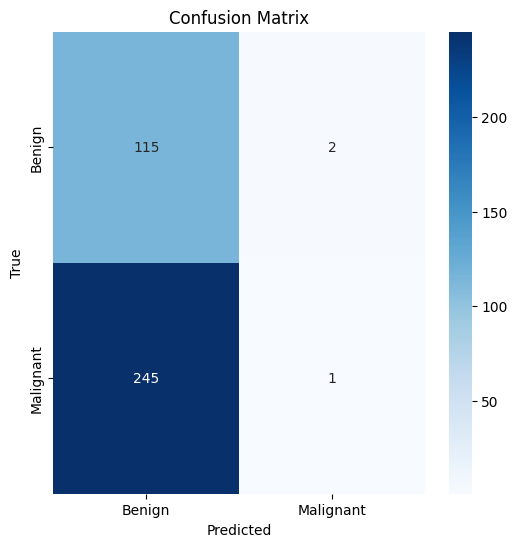

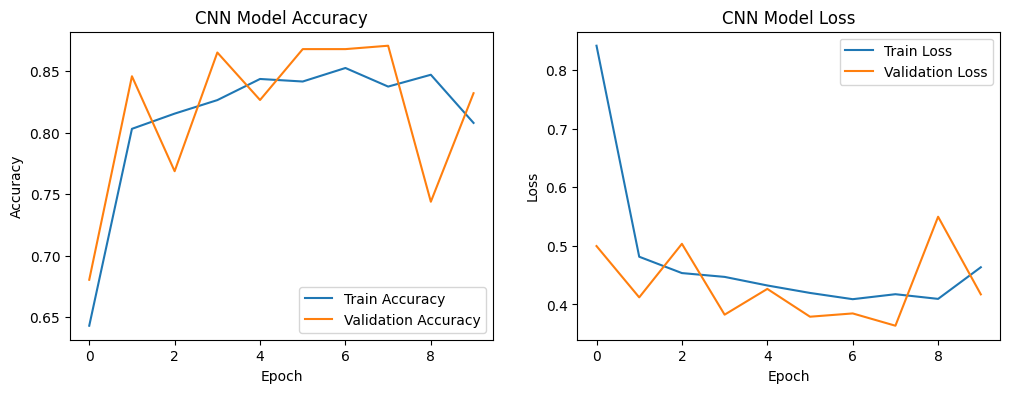

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.4308 - loss: 0.7031
Fully Connected Model Test Accuracy: 43.80%
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step
              precision    recall  f1-score   support

      Benign       0.32      0.59      0.42       117
   Malignant       0.68      0.41      0.51       246

    accuracy                           0.47       363
   macro avg       0.50      0.50      0.46       363
weighted avg       0.56      0.47      0.48       363



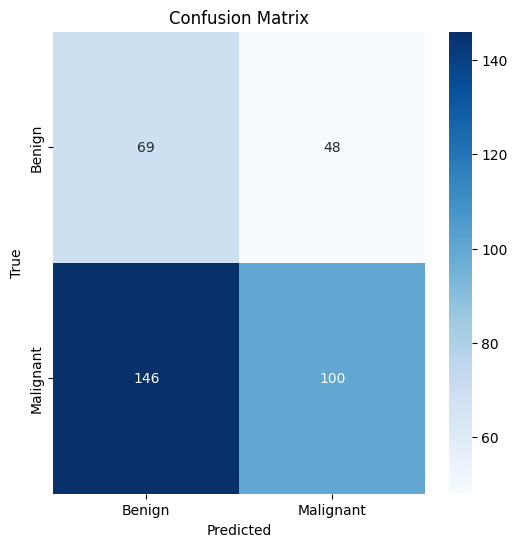

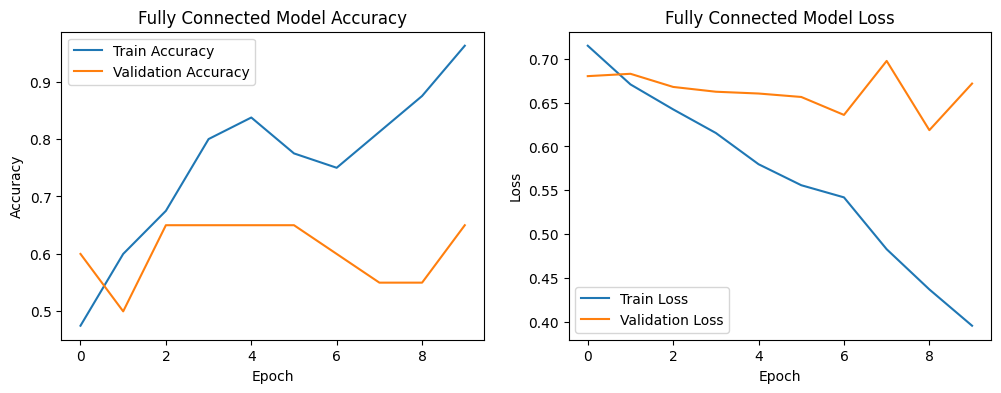

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate each model on the test set
def evaluate_model(model, test_generator, model_name):
    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"{model_name} Test Accuracy: {test_accuracy * 100:.2f}%")
    
    # Get predicted and true labels
    y_pred = (model.predict(test_generator) > 0.5).astype(int).flatten()  # For binary classification
    y_true = test_generator.classes if hasattr(test_generator, 'classes') else np.concatenate([test_generator[i][1] for i in range(len(test_generator))]).astype(int)
    
    # Classification report
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))
    
    # confusion matrix
    plot_confusion_matrix(y_true, y_pred, classes=['Benign', 'Malignant'])

#  training history
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Evaluate and plot of CNN model
evaluate_model(CNN_model, test_generator, "CNN Model")
plot_training_history(CNN_history, "CNN Model")

# Evaluate and plot of Fully Connected model
evaluate_model(fc_model, test_generator, "Fully Connected Model")
plot_training_history(fc_history, "Fully Connected Model")

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.3167 - loss: 0.7017
Transfer Learning Model (VGG16) Test Accuracy: 32.51%
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step
              precision    recall  f1-score   support

      Benign       0.32      0.99      0.49       117
   Malignant       0.67      0.01      0.02       246

    accuracy                           0.33       363
   macro avg       0.49      0.50      0.25       363
weighted avg       0.56      0.33      0.17       363



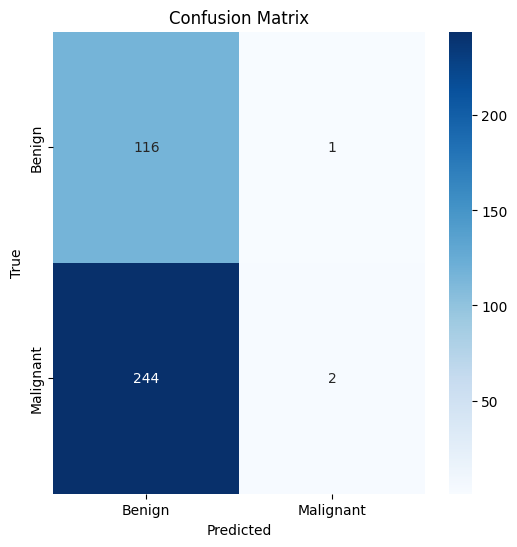

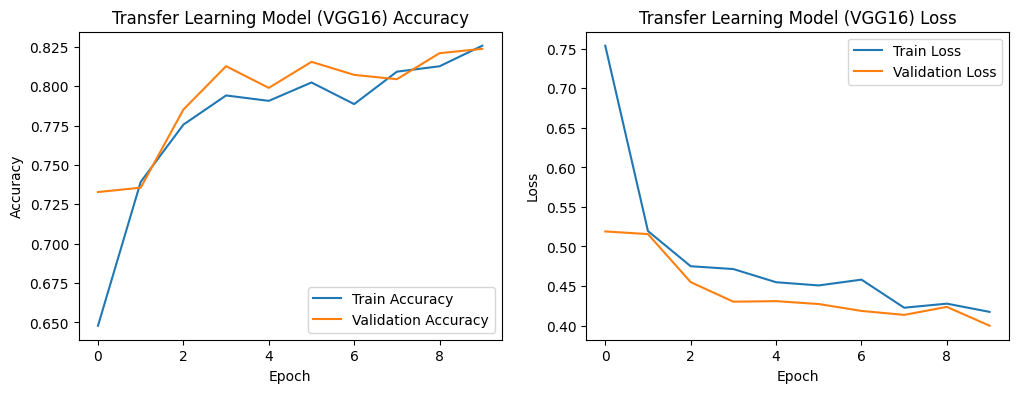

In [ ]:
# Evaluate and plot of Transfer Learning Model (VGG16)
evaluate_model(CNN_model, test_generator, "Transfer Learning Model (VGG16)")
plot_training_history(transfer_history, "Transfer Learning Model (VGG16)")